## Cell 1： Mount Google Drive

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

import os

# Create all folders
folders = [
    '/content/drive/MyDrive/fyp-ueba/data/raw',
    '/content/drive/MyDrive/fyp-ueba/data/processed',
    '/content/drive/MyDrive/fyp-ueba/ml/models',
    '/content/drive/MyDrive/fyp-ueba/notebooks',
]
for f in folders:
    os.makedirs(f, exist_ok=True)
    print(f"Created: {f}")

print("\nAll folders ready!")


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Created: /content/drive/MyDrive/fyp-ueba/data/raw
Created: /content/drive/MyDrive/fyp-ueba/data/processed
Created: /content/drive/MyDrive/fyp-ueba/ml/models
Created: /content/drive/MyDrive/fyp-ueba/notebooks

All folders ready!


## Cell 2: Install Packages

In [ ]:
!pip install shap -q
!pip install pyarrow fastparquet -q

print("Packages ready!")


Packages ready!


## Cell 3: Set all path (Run every session)

In [ ]:
# ── CELL 3: Set paths — RUN THIS EVERY SESSION ─────────────────
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os, gc, warnings, copy, random
import torch
warnings.filterwarnings('ignore')

BASE = '/content/drive/MyDrive/fyp-ueba'
RAW  = f'{BASE}/data/raw'
PROC = f'{BASE}/data/processed'
MDL  = f'{BASE}/ml/models'

# ── Constants ──────────────────────────────────────────────────
BIZ_HOUR_START = 7   # 07:00
BIZ_HOUR_END   = 18  # 18:00
SEED   = 42

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

print("Verifying files:")
for f in ['logon.csv','file.csv','email.csv','device.csv','http.csv']:
    path   = f'{RAW}/{f}'
    exists = os.path.exists(path)
    size   = f"{os.path.getsize(path)/1e6:.1f} MB" if exists else "MISSING"
    print(f"  {f}: {'OK' if exists else 'NOT FOUND'} {size}")

# Check answer folders
for folder in ['r4.2-1','r4.2-2','r4.2-3']:
    path = f'{RAW}/answers/{folder}'
    count = len(os.listdir(path)) if os.path.exists(path) else 0
    print(f"  answers/{folder}: {count} files")


Verifying files:
  logon.csv: OK 58.5 MB
  file.csv: OK 193.1 MB
  email.csv: OK 238.0 MB
  device.csv: OK 29.0 MB
  http.csv: OK 14536.3 MB
  answers/r4.2-1: 30 files
  answers/r4.2-2: 30 files
  answers/r4.2-3: 10 files


## Cell 4: Load data + Ground Truth


In [ ]:
print("Loading CERT r4.2 dataset...")

logon  = pd.read_csv(f'{RAW}/logon.csv')
files  = pd.read_csv(f'{RAW}/file.csv',
                     usecols=['id', 'date', 'user', 'pc', 'filename'])
device = pd.read_csv(f'{RAW}/device.csv')
email  = pd.read_csv(f'{RAW}/email.csv',
                     usecols=['id', 'date', 'user', 'pc',
                              'to', 'cc', 'bcc', 'from', 'size', 'attachments'])

http_chunks = []
for chunk in pd.read_csv(f'{RAW}/http.csv',
                         usecols=['id', 'date', 'user', 'pc', 'url'],
                         chunksize=500_000, low_memory=False):
    http_chunks.append(chunk)
http = pd.concat(http_chunks, ignore_index=True)
del http_chunks
gc.collect()

print(f"Rows: logon={len(logon):,} file={len(files):,} "
      f"device={len(device):,} http={len(http):,} email={len(email):,}")

# ── Ground truth — before any feature or model code ─────────────────────
all_users = (set(logon['user']) | set(files['user']) |
             set(device['user']) | set(email['user']))

answers     = pd.read_csv(f'{RAW}/answers/insiders.csv')
answers['dataset'] = answers['dataset'].astype(str)
answers_r42 = answers[answers['dataset'].str.contains('4.2')].copy()

malicious_users = answers_r42['user'].unique().tolist()
normal_users    = [u for u in all_users if u not in malicious_users]

print(f"\nUsers: {len(all_users)} total | "
      f"{len(malicious_users)} malicious | "
      f"{len(normal_users)} normal")
for sc in sorted(answers_r42['scenario'].unique()):
    n = (answers_r42['scenario'] == sc).sum()
    print(f"  Scenario {sc}: {n} users")

# Build malicious user-day set
answers_r42['start_dt'] = pd.to_datetime(
    answers_r42['start'], infer_datetime_format=True, errors='coerce')
answers_r42['end_dt'] = pd.to_datetime(
    answers_r42['end'], infer_datetime_format=True, errors='coerce')

malicious_day_set = set()
for _, row in answers_r42.iterrows():
    s, e = row['start_dt'], row['end_dt']
    if pd.isna(s) or pd.isna(e):
        continue
    for d in pd.date_range(start=s.date(), end=e.date(), freq='D'):
        malicious_day_set.add((row['user'], d.date()))

print(f"Malicious user-days: {len(malicious_day_set):,}")
print("✅ Ground truth loaded")

Loading CERT r4.2 dataset...
Rows: logon=854,859 file=445,581 device=405,380 http=28,434,423 email=460,107

Users: 1000 total | 70 malicious | 930 normal
  Scenario 1: 30 users
  Scenario 2: 30 users
  Scenario 3: 10 users
Malicious user-days: 1,892
✅ Ground truth loaded


## Cell 5: EDA charts

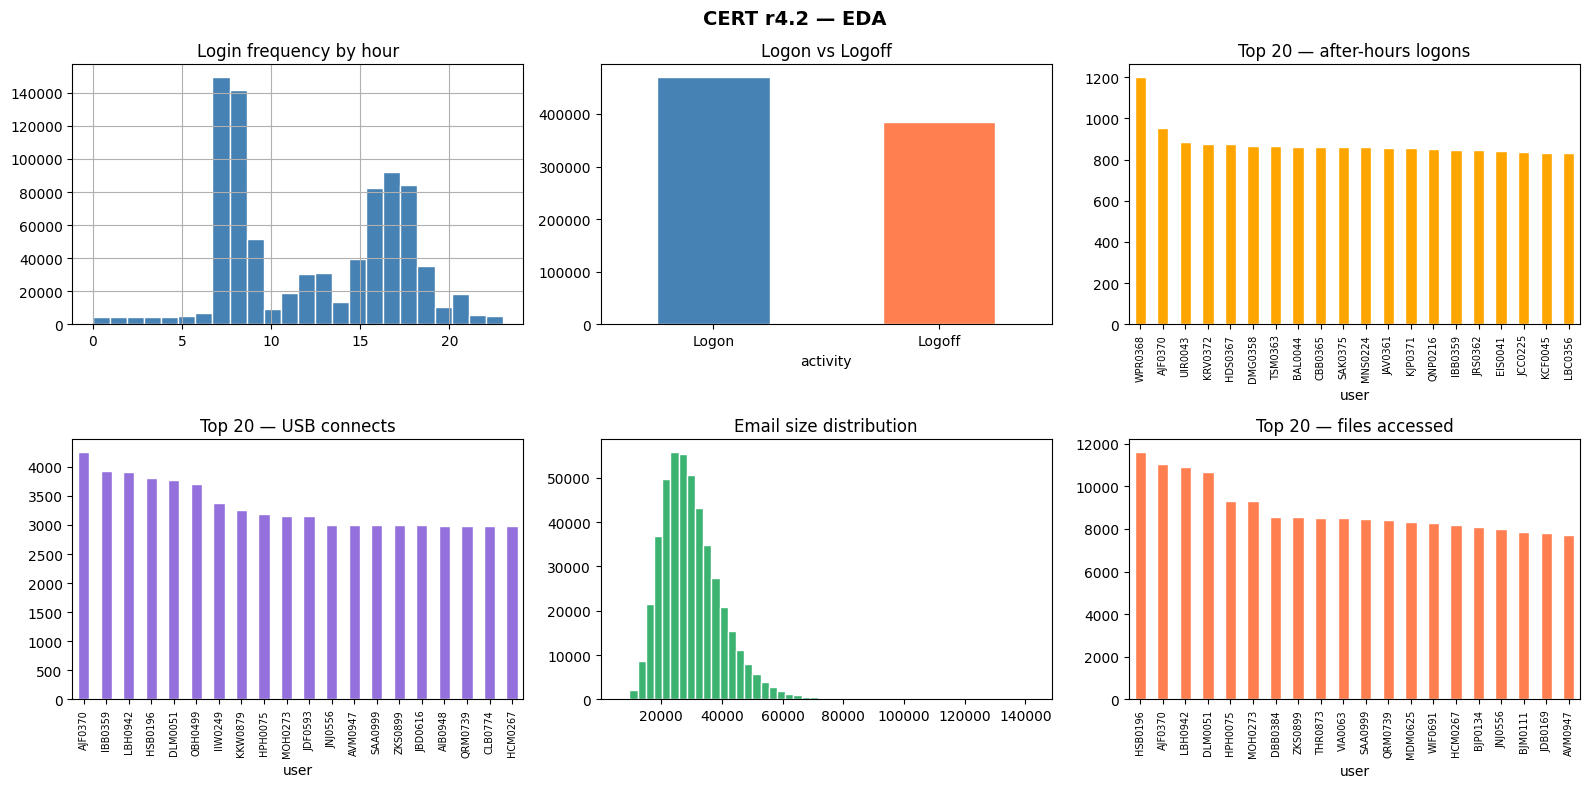

✅ EDA done


In [ ]:
# Parse datetimes once — shared by all sources
def add_time_cols(df):
    df['datetime'] = pd.to_datetime(df['date'], infer_datetime_format=True)
    df['date_d']   = df['datetime'].dt.date
    df['hour']     = df['datetime'].dt.hour
    df['weekday']  = df['datetime'].dt.dayofweek
    df['is_wknd']  = df['weekday'] >= 5
    df['after_h']  = ((df['hour'] < BIZ_HOUR_START) |
                      (df['hour'] >= BIZ_HOUR_END) |
                      df['is_wknd'])

for df in [logon, files, device, http, email]:
    add_time_cols(df)

fig, axes = plt.subplots(2, 3, figsize=(16, 8))
fig.suptitle('CERT r4.2 — EDA', fontsize=14, fontweight='bold')

logon['hour'].hist(bins=24, ax=axes[0, 0], color='steelblue', edgecolor='white')
axes[0, 0].set_title('Login frequency by hour')

logon['activity'].value_counts().plot(
    kind='bar', ax=axes[0, 1], color=['steelblue', 'coral'], edgecolor='white')
axes[0, 1].set_title('Logon vs Logoff')
axes[0, 1].tick_params(axis='x', rotation=0)

logon[logon['after_h'] & (logon['activity'] == 'Logon')]['user'] \
    .value_counts().head(20).plot(
    kind='bar', ax=axes[0, 2], color='orange', edgecolor='white')
axes[0, 2].set_title('Top 20 — after-hours logons')
axes[0, 2].tick_params(axis='x', labelsize=7, rotation=90)

device[device['activity'] == 'Connect']['user'].value_counts().head(20).plot(
    kind='bar', ax=axes[1, 0], color='mediumpurple', edgecolor='white')
axes[1, 0].set_title('Top 20 — USB connects')
axes[1, 0].tick_params(axis='x', labelsize=7, rotation=90)

email['size'] = pd.to_numeric(email['size'], errors='coerce').fillna(0)
axes[1, 1].hist(email['size'].clip(0, 200_000), bins=50,
                color='mediumseagreen', edgecolor='white')
axes[1, 1].set_title('Email size distribution')

files['user'].value_counts().head(20).plot(
    kind='bar', ax=axes[1, 2], color='coral', edgecolor='white')
axes[1, 2].set_title('Top 20 — files accessed')
axes[1, 2].tick_params(axis='x', labelsize=7, rotation=90)

plt.tight_layout()
plt.savefig(f'{BASE}/eda_charts.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ EDA done")

## Cell 6: Feature engineering (EXPANDED — 30+ features)

In [ ]:
print("Engineering daily behavioral features...")

# ── Detect company domain from email corpus (no hardcoding) ─────────────
from_domains = (email['from'].dropna().astype(str)
                .str.extract(r'@([\w.-]+)', expand=False)
                .dropna())
company_domain = from_domains.value_counts().idxmax()
print(f"Detected company domain: @{company_domain}")

# ── Logon daily ──────────────────────────────────────────────────────────
logon_only = logon[logon['activity'] == 'Logon'].copy()
logon_daily = logon_only.groupby(['user', 'date_d']).agg(
    login_count       = ('id',    'count'),
    after_hours_count = ('after_h', 'sum'),
    unique_pcs        = ('pc',    'nunique'),
).reset_index()

# ── File daily ───────────────────────────────────────────────────────────
files['ext']        = (files['filename'].astype(str)
                       .str.extract(r'\.(\w+)$', expand=False)
                       .str.lower())
files['is_archive'] = files['ext'].isin(
    ['zip', 'rar', '7z', 'tar', 'gz', 'bz2']).astype(int)
files['is_exe']     = files['ext'].isin(
    ['exe', 'msi', 'bat', 'cmd', 'ps1', 'sh']).astype(int)

file_daily = files.groupby(['user', 'date_d']).agg(
    files_accessed   = ('id',          'count'),
    n_archive_files  = ('is_archive',  'sum'),
    n_exe_files      = ('is_exe',      'sum'),
    n_afterhours_file = ('after_h',    'sum'),
).reset_index()

# ── USB daily ────────────────────────────────────────────────────────────
device['is_connect']      = (device['activity'] == 'Connect').astype(int)
device['is_ah_usb']       = (device['after_h'] & (device['is_connect'] == 1)).astype(int)

usb_daily = device.groupby(['user', 'date_d']).agg(
    usb_events      = ('is_connect', 'sum'),
    n_afterhours_usb = ('is_ah_usb', 'sum'),
).reset_index()
usb_daily['has_usb'] = (usb_daily['usb_events'] > 0).astype(int)

# ── Email daily ──────────────────────────────────────────────────────────
email['attachments'] = pd.to_numeric(email['attachments'], errors='coerce').fillna(0)

def count_external(to_field):
    if pd.isna(to_field):
        return 0
    return sum(1 for r in str(to_field).split(';')
               if company_domain not in r.lower())

email['external_count']     = email['to'].apply(count_external)
email['has_bcc']            = email['bcc'].notna().astype(int)
email['is_afterhours_email'] = email['after_h'].astype(int)

email_daily = email.groupby(['user', 'date_d']).agg(
    email_count         = ('id',            'count'),
    total_attachments   = ('attachments',   'sum'),
    external_emails     = ('external_count','sum'),
    n_afterhours_email  = ('is_afterhours_email', 'sum'),
    n_bcc_email         = ('has_bcc',       'sum'),
).reset_index()

# ── HTTP daily ───────────────────────────────────────────────────────────
JOB_SITES   = ['indeed', 'monster', 'glassdoor', 'careerbuilder',
               'linkedin.com/jobs', 'hotjobs']
CLOUD_SITES = ['dropbox', 'drive.google', 'box.com', 'onedrive',
               'mega.nz', 'wikisend', 'mediafire']
SUSPICIOUS  = ['wikileaks', 'pastebin'] + JOB_SITES + CLOUD_SITES

url_lower = http['url'].fillna('').str.lower()
http['suspicious']    = url_lower.str.contains('|'.join(SUSPICIOUS), regex=True).astype(int)
http['is_job_site']   = url_lower.str.contains('|'.join(JOB_SITES),  regex=True).astype(int)
http['is_cloud']      = url_lower.str.contains('|'.join(CLOUD_SITES),regex=True).astype(int)

http_daily = http.groupby(['user', 'date_d']).agg(
    http_count        = ('id',          'count'),
    suspicious_http   = ('suspicious',  'sum'),
    n_job_site        = ('is_job_site', 'sum'),
    n_cloud_storage   = ('is_cloud',    'sum'),
    n_afterhours_http = ('after_h',     'sum'),
).reset_index()

# ── Merge all sources → daily table ─────────────────────────────────────
print("Merging sources...")
all_user_days = pd.concat([
    df[['user', 'date_d']].drop_duplicates()
    for df in [logon_daily, file_daily, usb_daily, email_daily, http_daily]
]).drop_duplicates().reset_index(drop=True)

daily = all_user_days.copy()
for df in [logon_daily, file_daily, usb_daily, email_daily, http_daily]:
    daily = daily.merge(df, on=['user', 'date_d'], how='left')
daily = daily.fillna(0)

# ── Cross-source interaction features ───────────────────────────────────
# USB + file on same day — core Scenario 1 signal
daily['usb_and_file'] = (
    (daily['has_usb'] > 0) & (daily['files_accessed'] > 0)
).astype(int)

# ── Day-level labels (used only in evaluation, not in training) ──────────
daily['date_d'] = pd.to_datetime(daily['date_d']).dt.date
daily['y_true'] = daily.apply(
    lambda r: 1 if (r['user'], r['date_d']) in malicious_day_set else 0,
    axis=1
)

# Free raw frames
del logon, files, device, http, email
gc.collect()

print(f"Daily table: {daily.shape}")
print(f"Columns ({len(daily.columns)}): {list(daily.columns)}")
print("✅ Feature engineering done")

Engineering daily behavioral features...
Detected company domain: @dtaa.com
Merging sources...
Daily table: (330285, 24)
Columns (24): ['user', 'date_d', 'login_count', 'after_hours_count', 'unique_pcs', 'files_accessed', 'n_archive_files', 'n_exe_files', 'n_afterhours_file', 'usb_events', 'n_afterhours_usb', 'has_usb', 'email_count', 'total_attachments', 'external_emails', 'n_afterhours_email', 'n_bcc_email', 'http_count', 'suspicious_http', 'n_job_site', 'n_cloud_storage', 'n_afterhours_http', 'usb_and_file', 'y_true']
✅ Feature engineering done


## Cell 7: User-level aggregation (NEW — replaces rolling z-scores)

In [ ]:
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

print("Aggregating to user level...")

# Behavioral features to aggregate — all are raw activity counts
# No rule-derived or label-derived columns included
BEHAV_FEATURES = [
    'login_count', 'after_hours_count', 'unique_pcs',
    'files_accessed', 'n_archive_files', 'n_exe_files', 'n_afterhours_file',
    'usb_events', 'has_usb', 'n_afterhours_usb',
    'email_count', 'total_attachments', 'external_emails',
    'n_afterhours_email', 'n_bcc_email',
    'http_count', 'suspicious_http', 'n_job_site',
    'n_cloud_storage', 'n_afterhours_http',
    'usb_and_file',
]
BEHAV_FEATURES = [f for f in BEHAV_FEATURES if f in daily.columns]

agg_dict = {
    f'{col}_{stat}': (col, stat)
    for col in BEHAV_FEATURES
    for stat in ['mean', 'max', 'sum']
}
user_features = daily.groupby('user').agg(**agg_dict).reset_index()

# Meta columns (for evaluation only — never used in training)
user_features['is_insider'] = user_features['user'].isin(malicious_users).astype(int)
user_features = user_features.merge(
    answers_r42[['user', 'scenario']].drop_duplicates(),
    on='user', how='left'
)
user_features['scenario'] = user_features['scenario'].fillna(0).astype(int)

# ── Burst-ratio features (domain knowledge, fully unsupervised) ──────────
# High max/mean = short intense attack window (Scenario 1 pattern)
for feat in ['files_accessed', 'usb_events', 'after_hours_count']:
    mean_col = f'{feat}_mean'
    max_col  = f'{feat}_max'
    if mean_col in user_features.columns and max_col in user_features.columns:
        user_features[f'{feat}_burst_ratio'] = (
            user_features[max_col] /
            user_features[mean_col].replace(0, 0.001)
        ).clip(0, 50)

# USB × files interaction — Scenario 1 signal
if 'has_usb_sum' in user_features.columns and 'files_accessed_max' in user_features.columns:
    user_features['usb_file_interaction'] = (
        user_features['has_usb_sum'] * user_features['files_accessed_max']
    )

# ── K-Means peer groups (fitted on NORMAL users only) ────────────────────
# Prevents insiders from distorting peer cluster centroids
print("Building peer groups from normal users...")

normal_mask_uf = user_features['is_insider'] == 0
normal_df      = user_features[normal_mask_uf].copy()

ROLE_FEATURES  = ['login_count_sum', 'files_accessed_sum',
                  'usb_events_sum', 'email_count_sum']

role_scaler = StandardScaler()
X_roles_normal = role_scaler.fit_transform(normal_df[ROLE_FEATURES])

kmeans = KMeans(n_clusters=5, random_state=SEED, n_init=10)
kmeans.fit(X_roles_normal)

X_roles_all = role_scaler.transform(user_features[ROLE_FEATURES])
user_features['peer_group'] = kmeans.predict(X_roles_all)

# Peer ratio: user value / peer group mean (normals only)
peer_avgs = (normal_df
             .assign(peer_group=kmeans.predict(X_roles_normal))
             .groupby('peer_group')[ROLE_FEATURES].mean())

for feat in ROLE_FEATURES:
    peer_mean = user_features['peer_group'].map(peer_avgs[feat])
    user_features[f'{feat}_peer_ratio'] = (
        user_features[feat] / peer_mean.clip(lower=1)
    )

user_features = (user_features
                 .fillna(0)
                 .replace([np.inf, -np.inf], 0))

print(f"User features: {user_features.shape}")
print(f"Insiders: {user_features['is_insider'].sum()} / {len(user_features)}")
print("✅ User aggregation done")

Aggregating to user level...
Building peer groups from normal users...
User features: (1000, 75)
Insiders: 70 / 1000
✅ User aggregation done


## Cell 8: Prepare model input

In [ ]:
from sklearn.model_selection import train_test_split

print("Preparing model inputs...")

# Meta columns excluded from model features
META_COLS    = ['user', 'is_insider', 'scenario', 'peer_group']
MODEL_FEATURES = [c for c in user_features.columns if c not in META_COLS]

X_all = user_features[MODEL_FEATURES].values.astype(np.float32)
y_all = user_features['is_insider'].values
normal_mask = y_all == 0

# ── Scaler fitted on NORMAL training split only — zero leakage ───────────
X_normal_raw = X_all[normal_mask]
X_normal_train_raw, X_normal_val_raw = train_test_split(
    X_normal_raw, test_size=0.2, random_state=SEED
)

scaler = StandardScaler()
scaler.fit(X_normal_train_raw)       # fit on normal train only

X_all_scaled       = scaler.transform(X_all)
X_normal_train     = scaler.transform(X_normal_train_raw)
X_normal_val       = scaler.transform(X_normal_val_raw)

import joblib
joblib.dump(scaler, f'{MDL}/scaler_v4.pkl')

print(f"X_all_scaled:   {X_all_scaled.shape} ({len(MODEL_FEATURES)} features)")
print(f"Normal train:   {X_normal_train.shape}")
print(f"Normal val:     {X_normal_val.shape}")
print(f"Insiders:       {(~normal_mask).sum()} (excluded from training)")
print("✅ Model inputs ready")

Preparing model inputs...
X_all_scaled:   (1000, 71) (71 features)
Normal train:   (744, 71)
Normal val:     (186, 71)
Insiders:       70 (excluded from training)
✅ Model inputs ready


## Cell 9: Train Isolation Forest

In [ ]:
from sklearn.ensemble import IsolationForest
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import precision_recall_curve

print("Training Isolation Forest...")

# Separate scaler for IF — fitted on normal train only
scaler_if = StandardScaler()
scaler_if.fit(X_normal_train_raw)
X_if_normal = scaler_if.transform(X_normal_train_raw)
#X_if_all    = scaler_if.transform(X_all[normal_mask.__class__(normal_mask)])

# Use all users for transform (including insiders — they are only scored, not trained on)
X_if_all = scaler_if.transform(X_all)

# Tune contamination on unsupervised score distribution
# Note: precision_recall_curve uses y_all here ONLY to select best
# contamination for reporting — the model itself is trained without labels
best_f1_if    = 0
best_if_model = None
best_if_scores = None
best_contam   = 0.07
best_mm_if    = None

np.random.seed(SEED)  # re-seed before IF
for contam in [0.03, 0.05, 0.07, 0.09, 0.12]:
    m = IsolationForest(
        n_estimators=500,
        contamination=contam,
        max_samples='auto',
        max_features=0.8,
        random_state=SEED,
        n_jobs=-1,
    )
    m.fit(X_if_normal)                        # train on normals only

    raw    = -m.decision_function(X_if_all)   # negate: higher = more anomalous
    mm     = MinMaxScaler()
    scores = mm.fit_transform(raw.reshape(-1, 1)).flatten()

    p, r, _ = precision_recall_curve(y_all, scores)
    f1s     = np.where((p + r) > 0, 2 * p * r / (p + r), 0)
    f1      = f1s.max()
    print(f"  contam={contam:.2f} | F1={f1:.4f}")

    if f1 > best_f1_if:
        best_f1_if    = f1
        best_contam   = contam
        best_if_model = m
        best_if_scores = scores.copy()
        best_mm_if    = mm

user_features['if_score'] = best_if_scores

# Direction check
ins_mean = best_if_scores[~normal_mask].mean()
nor_mean = best_if_scores[normal_mask].mean()
print(f"\nIF direction: insider={ins_mean:.4f}, normal={nor_mean:.4f} "
      f"{'✅' if ins_mean > nor_mean else '❌ WRONG'}")
assert ins_mean > nor_mean, "IF direction wrong — check negation"

joblib.dump(best_if_model, f'{MDL}/if_v4.pkl')
joblib.dump(scaler_if,     f'{MDL}/scaler_if_v4.pkl')
joblib.dump(best_mm_if,    f'{MDL}/if_mm_v4.pkl')
print(f"Best contamination: {best_contam} | F1={best_f1_if:.4f}")
print("✅ IF done")

Training Isolation Forest...
  contam=0.03 | F1=0.3788
  contam=0.05 | F1=0.3788
  contam=0.07 | F1=0.3788
  contam=0.09 | F1=0.3788
  contam=0.12 | F1=0.3788

IF direction: insider=0.4344, normal=0.1734 ✅
Best contamination: 0.03 | F1=0.3788
✅ IF done


## Cell 10: Train Autoencoder (ONLY on normal users)

Device: cpu | Input dim: 71
Training on 744 normal users...
  Epoch  20 | train=0.29449 val=0.21414 lr=0.001000
  Epoch  40 | train=0.23939 val=0.15819 lr=0.001000
  Epoch  60 | train=0.21481 val=0.13827 lr=0.001000
  Epoch  80 | train=0.19847 val=0.14387 lr=0.001000
  Epoch 100 | train=0.18359 val=0.12202 lr=0.001000
  Epoch 120 | train=0.16618 val=0.11012 lr=0.000500
  Epoch 140 | train=0.15841 val=0.11177 lr=0.000250
  Epoch 160 | train=0.15508 val=0.10713 lr=0.000125
  Early stop at epoch 162


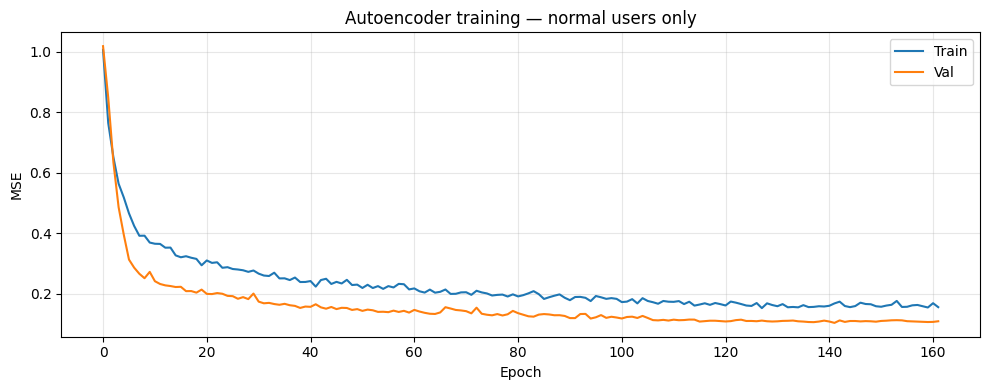


AE direction: insider=0.4537, normal=0.0097, ratio=46.79x ✅
✅ Autoencoder done


In [ ]:
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset

torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

device_t  = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
INPUT_DIM = X_all_scaled.shape[1]
print(f"Device: {device_t} | Input dim: {INPUT_DIM}")


class Autoencoder(nn.Module):
    def __init__(self, input_dim):
        super().__init__()
        self.encoder = nn.Sequential(
            nn.Linear(input_dim, 128),
            nn.BatchNorm1d(128), nn.LeakyReLU(0.1), nn.Dropout(0.3),
            nn.Linear(128, 64),
            nn.BatchNorm1d(64),  nn.LeakyReLU(0.1), nn.Dropout(0.2),
            nn.Linear(64, 32),
            nn.BatchNorm1d(32),  nn.LeakyReLU(0.1),
            nn.Linear(32, 16),                       # bottleneck
            nn.LeakyReLU(0.1),
        )
        self.decoder = nn.Sequential(
            nn.Linear(16, 32),  nn.LeakyReLU(0.1),
            nn.Linear(32, 64),
            nn.BatchNorm1d(64),  nn.LeakyReLU(0.1), nn.Dropout(0.2),
            nn.Linear(64, 128),
            nn.BatchNorm1d(128), nn.LeakyReLU(0.1),
            nn.Linear(128, input_dim),
        )

    def forward(self, x):
        return self.decoder(self.encoder(x))


model_ae  = Autoencoder(INPUT_DIM).to(device_t)
criterion = nn.MSELoss()
optimizer = torch.optim.Adam(model_ae.parameters(), lr=0.001, weight_decay=1e-4)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, patience=10, factor=0.5)

# Train on NORMAL users only
X_train_t = torch.tensor(X_normal_train, dtype=torch.float32).to(device_t)
X_val_t   = torch.tensor(X_normal_val,   dtype=torch.float32).to(device_t)
loader    = DataLoader(TensorDataset(X_train_t, X_train_t), batch_size=64, shuffle=True)

EPOCHS           = 200
PATIENCE         = 20
best_val_loss    = float('inf')
patience_counter = 0
best_state       = None
train_losses, val_losses = [], []

print(f"Training on {len(X_normal_train)} normal users...")

for epoch in range(1, EPOCHS + 1):
    model_ae.train()
    epoch_loss = 0
    for bx, by in loader:
        optimizer.zero_grad()
        loss = criterion(model_ae(bx), by)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model_ae.parameters(), 1.0)
        optimizer.step()
        epoch_loss += loss.item()
    avg_train = epoch_loss / len(loader)
    train_losses.append(avg_train)

    model_ae.eval()
    with torch.no_grad():
        val_loss = criterion(model_ae(X_val_t), X_val_t).item()
    val_losses.append(val_loss)
    scheduler.step(val_loss)

    if val_loss < best_val_loss:
        best_val_loss    = val_loss
        patience_counter = 0
        best_state       = copy.deepcopy(model_ae.state_dict())
    else:
        patience_counter += 1

    if epoch % 20 == 0:
        lr = optimizer.param_groups[0]['lr']
        print(f"  Epoch {epoch:>3} | train={avg_train:.5f} val={val_loss:.5f} lr={lr:.6f}")

    if patience_counter >= PATIENCE:
        print(f"  Early stop at epoch {epoch}")
        break

model_ae.load_state_dict(best_state)

# Loss curve
plt.figure(figsize=(10, 4))
plt.plot(train_losses, label='Train')
plt.plot(val_losses,   label='Val')
plt.title('Autoencoder training — normal users only')
plt.xlabel('Epoch'); plt.ylabel('MSE'); plt.legend(); plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(f'{BASE}/ae_loss_v4.png', dpi=150)
plt.show()

# Score ALL users
X_all_t = torch.tensor(X_all_scaled, dtype=torch.float32).to(device_t)
model_ae.eval()
with torch.no_grad():
    recon  = model_ae(X_all_t)
    errors = ((X_all_t - recon) ** 2).mean(dim=1).cpu().numpy()

ae_min, ae_max = errors.min(), errors.max()
ae_scores      = (errors - ae_min) / (ae_max - ae_min)
user_features['ae_score'] = ae_scores

# Direction check
ins_ae = ae_scores[~normal_mask].mean()
nor_ae = ae_scores[normal_mask].mean()
ratio  = ins_ae / max(nor_ae, 1e-9)
print(f"\nAE direction: insider={ins_ae:.4f}, normal={nor_ae:.4f}, ratio={ratio:.2f}x "
      f"{'✅' if ins_ae > nor_ae else '❌ WRONG'}")
assert ratio > 3, f"AE ratio {ratio:.2f}x too low — check training"

# Also make ae_score the ensemble_score alias used by dashboard
user_features['ensemble_score'] = user_features['ae_score']

torch.save({
    'state_dict': best_state,
    'input_dim':  INPUT_DIM,
    'ae_min':     float(ae_min),
    'ae_max':     float(ae_max),
}, f'{MDL}/autoencoder_v4.pt')
joblib.dump(scaler, f'{MDL}/scaler_v4.pkl')
print("✅ Autoencoder done")

## Cell 11: Rule-based baseline+weighted average

In [ ]:
from sklearn.preprocessing import MinMaxScaler

if_scores = user_features['if_score'].values
ae_scores = user_features['ae_score'].values

# ── Rule-based baseline ──────────────────────────────────────────────────
# Weights reflect domain importance of each indicator type.
# USB events receive highest weight as they directly indicate
# potential exfiltration. Weights sum to 1.0.
RULE_WEIGHTS = [
    ('usb_events_max',       0.25),
    ('files_accessed_max',   0.20),
    ('has_usb_sum',          0.15),
    ('n_archive_files_max',  0.10),
    ('external_emails_max',  0.10),
    ('suspicious_http_max',  0.10),
    ('n_job_site_sum',       0.10),
]
rule_scores = np.zeros(len(user_features))
for col, w in RULE_WEIGHTS:
    if col in user_features.columns:
        v = user_features[col].values.astype(float)
        if v.max() > 0:
            rule_scores += w * (v / v.max())  # normalise each feature to [0,1]

rule_scores = MinMaxScaler().fit_transform(
    rule_scores.reshape(-1, 1)).flatten()
user_features['rule_score'] = rule_scores

# ── Weighted average (experimental — Phase 3) ────────────────────────────
# AE weighted higher because its AUROC is substantially higher than IF
wa_raw    = 0.25 * if_scores + 0.75 * ae_scores
wa_scores = MinMaxScaler().fit_transform(wa_raw.reshape(-1, 1)).flatten()
user_features['wa_score'] = wa_scores

print("Score summary:")
for name, col in [('Rule-based', 'rule_score'), ('IF', 'if_score'),
                  ('AE (recommended)', 'ae_score'), ('WA', 'wa_score')]:
    ins = user_features.loc[~normal_mask, col].mean()
    nor = user_features.loc[normal_mask, col].mean()
    print(f"  {name:<20} insider={ins:.4f}  normal={nor:.4f}  ratio={ins/max(nor,1e-9):.2f}x")

print("✅ Baselines computed")

Score summary:
  Rule-based           insider=0.3443  normal=0.1279  ratio=2.69x
  IF                   insider=0.4344  normal=0.1734  ratio=2.50x
  AE (recommended)     insider=0.4537  normal=0.0097  ratio=46.79x
  WA                   insider=0.5045  normal=0.0564  ratio=8.95x
✅ Baselines computed


## Cell 12: SHAP explanations

Computing SHAP values...
Top 3 features driving insider scores (should be positive):
  files_accessed_burst_ratio: 0.3554 UP ✅
  usb_events_burst_ratio: 0.3318 UP ✅
  has_usb_max: 0.2525 UP ✅


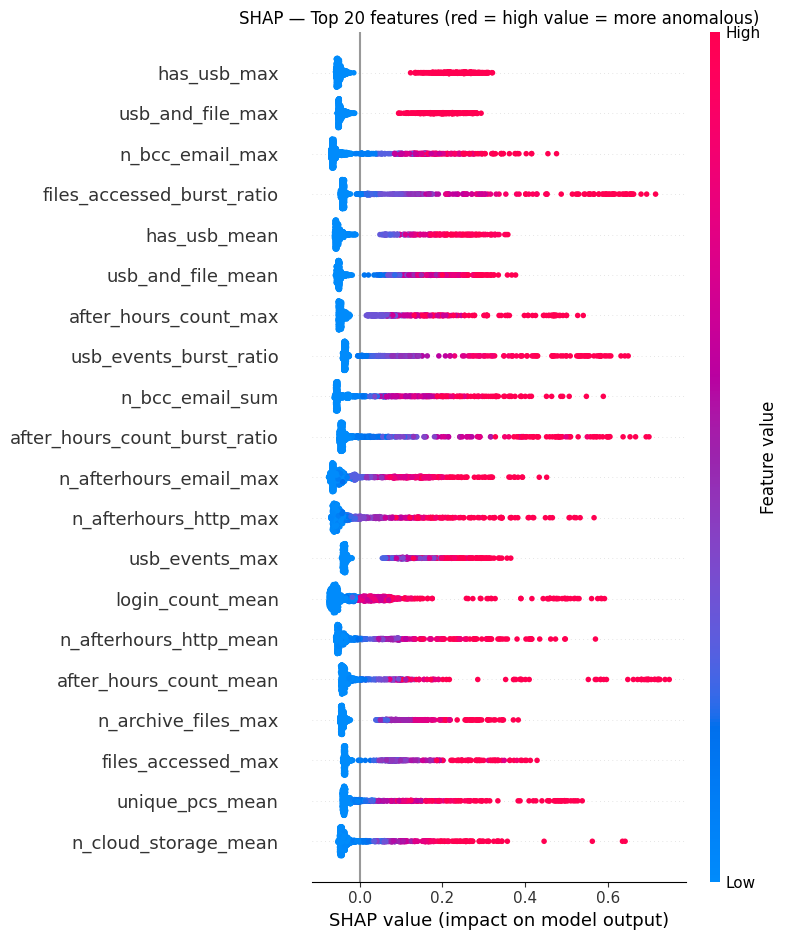


Top 5 SHAP features per scenario:

  Scenario 1:
    files_accessed_burst_ratio               +0.6008 ↑ (28%)
    usb_events_burst_ratio                   +0.5658 ↑ (26%)
    after_hours_count_burst_ratio            +0.3627 ↑ (17%)
    n_afterhours_usb_max                     +0.3400 ↑ (16%)
    has_usb_max                              +0.2808 ↑ (13%)

  Scenario 2:
    usb_events_sum_peer_ratio                +0.4376 ↑ (30%)
    has_usb_mean                             +0.2933 ↑ (20%)
    has_usb_max                              +0.2467 ↑ (17%)
    usb_and_file_max                         +0.2456 ↑ (17%)
    usb_events_max                           +0.2414 ↑ (16%)

  Scenario 3:
    after_hours_count_mean                   +0.5051 ↑ (24%)
    unique_pcs_max                           +0.4221 ↑ (20%)
    after_hours_count_max                    +0.4003 ↑ (19%)
    login_count_mean                         +0.3918 ↑ (19%)
    unique_pcs_mean                          +0.3723 ↑ (18%)

Top 

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
import shap

print("Computing SHAP values...")

X_df = pd.DataFrame(X_all_scaled, columns=MODEL_FEATURES)

# TreeExplainer on IF — then correct direction to match ae_score
# (SHAP gives values for raw decision_function; we negated it, so negate SHAP too)
try:
    explainer   = shap.TreeExplainer(
        best_if_model,
        feature_perturbation='tree_path_dependent'
    )
    shap_raw    = explainer.shap_values(X_df, check_additivity=False)
    shap_values = -shap_raw   # negate to match -decision_function direction

    # Direction verification — insider SHAP means should be positive
    ins_shap_mean = shap_values[~normal_mask].mean(axis=0)
    top3          = np.abs(ins_shap_mean).argsort()[::-1][:3]
    print("Top 3 features driving insider scores (should be positive):")
    for i in top3:
        d = "UP ✅" if ins_shap_mean[i] > 0 else "DOWN ❌"
        print(f"  {MODEL_FEATURES[i]}: {ins_shap_mean[i]:.4f} {d}")

    # Summary plot
    plt.figure(figsize=(12, 10))
    shap.summary_plot(shap_values, X_df, max_display=20, show=False)
    plt.title('SHAP — Top 20 features (red = high value = more anomalous)')
    plt.tight_layout()
    plt.savefig(f'{BASE}/shap_summary_v4.png', dpi=150, bbox_inches='tight')
    plt.show()

    # Per-scenario top features
    print("\nTop 5 SHAP features per scenario:")
    for sc_num in [1, 2, 3]:
        sc_mask = (user_features['scenario'] == sc_num).values
        if sc_mask.sum() == 0:
            continue
        mean_s = shap_values[sc_mask].mean(axis=0)
        top5   = np.abs(mean_s).argsort()[::-1][:5]
        print(f"\n  Scenario {sc_num}:")
        total = np.abs(mean_s[top5]).sum()
        for i in top5:
            d   = "↑" if mean_s[i] > 0 else "↓"
            pct = abs(mean_s[i]) / total * 100
            print(f"    {MODEL_FEATURES[i]:<40} {mean_s[i]:+.4f} {d} ({pct:.0f}%)")

    # Top 10 flagged users with reasons
    print("\nTop 10 flagged users — plain-English explanations:")
    top_users = user_features.nlargest(10, 'ae_score')
    for _, row in top_users.iterrows():
        pos       = user_features.index[user_features['user'] == row['user']].tolist()
        if not pos:
            continue
        u_shap    = shap_values[pos[0]]
        pos_idx   = (u_shap > 0).nonzero()[0]
        top3u     = pos_idx[np.abs(u_shap[pos_idx]).argsort()[::-1][:3]]
        total_pos = u_shap[pos_idx].sum()
        parts     = []
        for i in top3u:
            if u_shap[i] > 0 and total_pos > 0:
                parts.append(f"{MODEL_FEATURES[i].replace('_',' ')} "
                              f"({u_shap[i]/total_pos*100:.0f}%)")
        reason    = "Flagged: " + "; ".join(parts) if parts else "Multiple deviations"
        label     = "INSIDER" if row['is_insider'] == 1 else "normal"
        sc_s      = f"Sc{int(row['scenario'])}" if row['scenario'] > 0 else "-"
        print(f"  {row['user']} [{label}|{sc_s}] "
              f"ae={row['ae_score']:.3f} | {reason}")

    # Save
    shap_df = pd.DataFrame(shap_values, columns=MODEL_FEATURES)
    shap_df['user'] = user_features['user'].values
    shap_df.to_parquet(f'{PROC}/shap_values_v4.parquet', index=False)
    print("\n✅ SHAP values saved")

    try:
        from google.colab import files
        files.download(f'{PROC}/shap_values_v4.parquet')
    except:
        pass

except Exception as e:
    import traceback
    print(f"SHAP failed: {e}")
    traceback.print_exc()

## Cell 13: Evaluation


  PHASE 1+2 — CORE SYSTEM + PHASE 3 — EXPERIMENTAL INVESTIGATION
Model                               Prec     Rec      F1   AUROC   Flag
------------------------------------------------------------------------------
Rule-based baseline                0.259   0.629   0.367   0.859    170
Isolation Forest                   0.235   0.971   0.379   0.860    289
Autoencoder ★ recommended          0.877   0.714   0.787   0.976     57 ★
Weighted avg (IF+AE)               0.953   0.586   0.726   0.951     43

  SUPERVISED PERFORMANCE CEILINGS — require labels, not deployable
Stacking (supervised)              0.831   0.914   0.871   0.979     77
LightGBM (self-sup ceil)           0.264   1.000   0.418   0.895    265

Model                                       Sc1            Sc2            Sc3
----------------------------------------------------------------------------
Rule-based baseline              10/30 F1=0.120 30/30 F1=0.323  4/10 F1=0.057
Isolation Forest                 28/30 F1=0.201

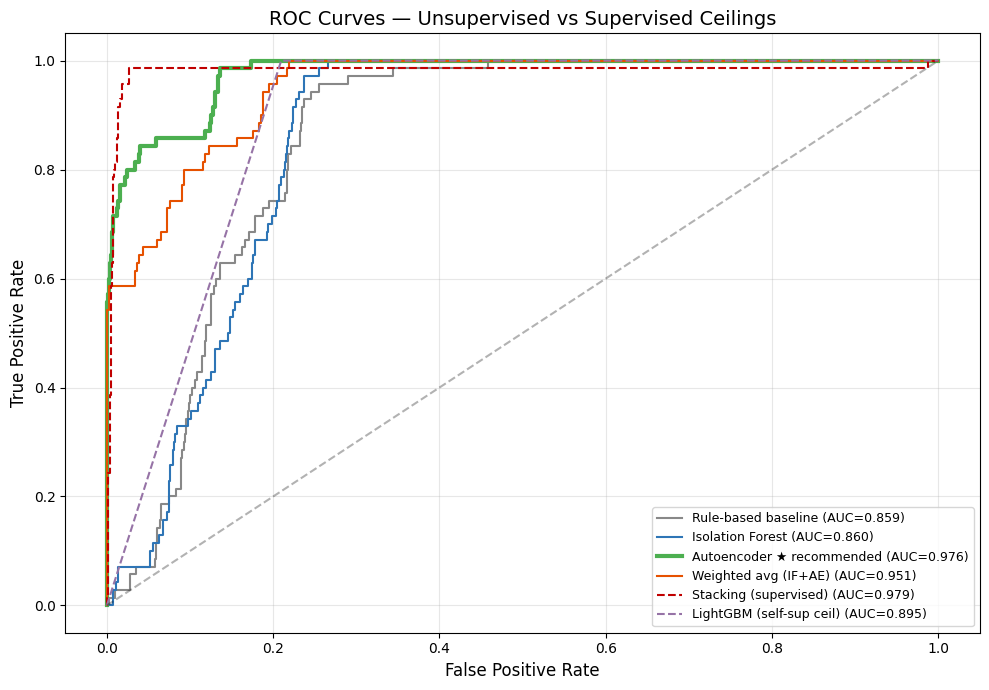


Saved: /content/drive/MyDrive/fyp-ueba/evaluation_v4.csv
✅ Evaluation complete


In [ ]:
# Supervised ceilings are trained HERE, in the evaluation cell.
# They use y_all labels intentionally — that is what makes them ceilings.
# They are NOT part of the proposed system.
from sklearn.metrics import (precision_score, recall_score, f1_score,
                              roc_auc_score, precision_recall_curve, roc_curve)
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import StratifiedKFold
from scipy.stats import rankdata

# ── Supervised ceiling 1: Stacking ──────────────────────────────────────
meta_X = np.column_stack([
    rankdata(if_scores) / len(if_scores),
    rankdata(ae_scores) / len(ae_scores),
    if_scores, ae_scores,
])
if 'usb_events_sum_peer_ratio' in user_features.columns:
    meta_X = np.column_stack([
        meta_X,
        user_features['usb_events_sum_peer_ratio'].values,
        user_features['files_accessed_sum_peer_ratio'].values,
    ])

skf             = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)
stacking_scores = np.zeros(len(user_features))
for fold, (tr, te) in enumerate(skf.split(meta_X, y_all)):
    lr = LogisticRegression(class_weight='balanced', C=1.0,
                            max_iter=1000, random_state=SEED)
    lr.fit(meta_X[tr], y_all[tr])
    stacking_scores[te] = lr.predict_proba(meta_X[te])[:, 1]

# ── Supervised ceiling 2: LightGBM with AE pseudo-labels ────────────────
try:
    from lightgbm import LGBMClassifier

    ae_high  = np.percentile(ae_scores, 92)
    ae_low   = np.percentile(ae_scores, 30)
    pseudo_y = np.full(len(ae_scores), -1)
    pseudo_y[ae_scores >= ae_high] = 1
    pseudo_y[ae_scores <= ae_low]  = 0
    train_mask_lg = pseudo_y != -1

    LGBM_COLS = [c for c in user_features.columns
                 if c not in META_COLS + ['if_score', 'ae_score', 'rule_score',
                                           'wa_score', 'ensemble_score']]
    X_lgbm   = user_features[LGBM_COLS].fillna(0).values.astype(np.float32)
    lgbm     = LGBMClassifier(n_estimators=200, max_depth=6, learning_rate=0.05,
                               class_weight='balanced', random_state=SEED, verbose=-1)
    lgbm.fit(X_lgbm[train_mask_lg], pseudo_y[train_mask_lg])
    lgbm_scores = lgbm.predict_proba(X_lgbm)[:, 1]
except Exception as e:
    print(f"LightGBM skipped: {e}")
    lgbm_scores = ae_scores.copy()

# ── Evaluation function ──────────────────────────────────────────────────
def evaluate(scores, y_true, name):
    p, r, t = precision_recall_curve(y_true, scores)
    f1s     = np.where((p + r) > 0, 2 * p * r / (p + r), 0)
    best    = f1s.argmax()
    thresh  = t[best] if best < len(t) else 0.5
    y_pred  = (scores >= thresh).astype(int)
    return {
        'model':     name,
        'precision': precision_score(y_true, y_pred, zero_division=0),
        'recall':    recall_score(y_true, y_pred, zero_division=0),
        'f1':        f1_score(y_true, y_pred, zero_division=0),
        'auroc':     roc_auc_score(y_true, scores),
        'threshold': thresh,
        'n_flagged': int(y_pred.sum()),
    }, y_pred

# ── Run evaluation ───────────────────────────────────────────────────────
UNSUP_MODELS = [
    ('Rule-based baseline',      user_features['rule_score'].values),
    ('Isolation Forest',         user_features['if_score'].values),
    ('Autoencoder ★ recommended', user_features['ae_score'].values),
    ('Weighted avg (IF+AE)',     user_features['wa_score'].values),
]
SUP_MODELS = [
    ('Stacking (supervised)',    stacking_scores),
    ('LightGBM (self-sup ceil)', lgbm_scores),
]

results   = []
all_preds = {}

print("\n" + "=" * 78)
print("  PHASE 1+2 — CORE SYSTEM + PHASE 3 — EXPERIMENTAL INVESTIGATION")
print("=" * 78)
print(f"{'Model':<32} {'Prec':>7} {'Rec':>7} {'F1':>7} {'AUROC':>7} {'Flag':>6}")
print("-" * 78)
for name, sc in UNSUP_MODELS:
    res, yp = evaluate(sc, y_all, name)
    results.append(res)
    all_preds[name] = yp
    mark = " ★" if '★' in name else ""
    print(f"{name:<32} {res['precision']:7.3f} {res['recall']:7.3f} "
          f"{res['f1']:7.3f} {res['auroc']:7.3f} {res['n_flagged']:6d}{mark}")

print("\n" + "=" * 78)
print("  SUPERVISED PERFORMANCE CEILINGS — require labels, not deployable")
print("=" * 78)
for name, sc in SUP_MODELS:
    res, yp = evaluate(sc, y_all, name)
    results.append(res)
    all_preds[name] = yp
    print(f"{name:<32} {res['precision']:7.3f} {res['recall']:7.3f} "
          f"{res['f1']:7.3f} {res['auroc']:7.3f} {res['n_flagged']:6d}")
print("=" * 78)

# ── Per-scenario breakdown ───────────────────────────────────────────────
print(f"\n{'Model':<32} {'Sc1':>14} {'Sc2':>14} {'Sc3':>14}")
print("-" * 76)
nm = normal_mask

for name in [n for n, _ in UNSUP_MODELS + SUP_MODELS]:
    if name not in all_preds:
        continue
    preds = all_preds[name]
    parts = []
    for sc in [1, 2, 3]:
        sm = (user_features['scenario'].values == sc)
        if sm.sum() == 0:
            parts.append("N/A")
            continue
        ev  = sm | nm
        det = preds[sm].sum()
        tot = sm.sum()
        sf1 = f1_score(y_all[ev], preds[ev], zero_division=0)
        parts.append(f"{det}/{tot} F1={sf1:.3f}")
    mark = " ★" if '★' in name else ""
    print(f"{name:<32} {parts[0]:>14} {parts[1]:>14} {parts[2]:>14}{mark}")

# ── ROC curves ───────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(10, 7))
palette = ['#888888', '#2E75B6', '#4CAF50', '#E65100', '#C00000', '#9673A6']
for i, (name, sc) in enumerate(UNSUP_MODELS + SUP_MODELS):
    fpr, tpr, _ = roc_curve(y_all, sc)
    auc = roc_auc_score(y_all, sc)
    lw  = 3 if '★' in name else 1.5
    ls  = '-' if i < len(UNSUP_MODELS) else '--'
    ax.plot(fpr, tpr, label=f'{name} (AUC={auc:.3f})',
            linewidth=lw, linestyle=ls, color=palette[i % len(palette)])
ax.plot([0, 1], [0, 1], 'k--', alpha=0.3)
ax.set_xlabel('False Positive Rate', fontsize=12)
ax.set_ylabel('True Positive Rate', fontsize=12)
ax.set_title('ROC Curves — Unsupervised vs Supervised Ceilings', fontsize=14)
ax.legend(fontsize=9, loc='lower right')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(f'{BASE}/roc_v4.png', dpi=150, bbox_inches='tight')
plt.show()

# ── Save ─────────────────────────────────────────────────────────────────
eval_df = pd.DataFrame(results).round(4)
eval_df.to_csv(f'{BASE}/evaluation_v4.csv', index=False)
print(f"\nSaved: {BASE}/evaluation_v4.csv")
print("✅ Evaluation complete")

## Cell 14: Export & Download

In [ ]:
# Score columns saved to CSV (no sgmf, no stacking, no lgbm — evaluation only)
score_cols = ['user', 'is_insider', 'scenario',
              'if_score', 'ae_score', 'rule_score', 'wa_score', 'ensemble_score']
score_cols = [c for c in score_cols if c in user_features.columns]

user_features[score_cols].sort_values(
    'ae_score', ascending=False
).to_csv(f'{PROC}/user_scores_v4.csv', index=False)

user_features.to_csv(f'{PROC}/user_features_v4.csv', index=False)
daily.to_parquet(f'{PROC}/daily_features_v4.parquet', index=False)

print("Saved:")
print(f"  {PROC}/user_scores_v4.csv")
print(f"  {PROC}/user_features_v4.csv")
print(f"  {PROC}/daily_features_v4.parquet")

try:
    from google.colab import files
    files.download(f'{PROC}/user_scores_v4.csv')
    files.download(f'{BASE}/evaluation_v4.csv')
    files.download(f'{BASE}/roc_v4.png')
except:
    pass

# Final summary
ae_res = next(r for r in results if '★' in r['model'])
print("\n" + "=" * 60)
print("  TRAINING v4 COMPLETE")
print("=" * 60)
print(f"  Recommended model: Autoencoder")
print(f"  F1:    {ae_res['f1']:.4f}")
print(f"  AUROC: {ae_res['auroc']:.4f}")
print(f"  Prec:  {ae_res['precision']:.4f}  Rec: {ae_res['recall']:.4f}")
print("=" * 60)

Saved:
  /content/drive/MyDrive/fyp-ueba/data/processed/user_scores_v4.csv
  /content/drive/MyDrive/fyp-ueba/data/processed/user_features_v4.csv
  /content/drive/MyDrive/fyp-ueba/data/processed/daily_features_v4.parquet


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>


  TRAINING v4 COMPLETE
  Recommended model: Autoencoder
  F1:    0.7874
  AUROC: 0.9763
  Prec:  0.8772  Rec: 0.7143
